# DS-7331 Lab Two -

### By Ahmad Salama, Titus Karuri, Eman Meraj, Sue Camara

In [128]:
# ---------------------------------------------------------
# Python Library Setup: Check and Install Required Dependencies
# ---------------------------------------------------------
import sys
import subprocess
import importlib.util as imp_util

# List of required libraries\packages for this notebook
required_packages = [
    "pandas",
    "missingno",
    "seaborn",
    "matplotlib",
    "math",
    "scikit-learn",
    "numpy"
]

for package in required_packages:
    # iterate over the required packages and if any is not installed, trigger a pip command
    # to install.
    if imp_util.find_spec(package) is None:
        print(f"Package '{package}' is not installed. Installing now...")
        # run the pip command
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL
        )
        print(f"Package '{package}' installed successfully.\n")
    else:
        print(f"Package '{package}' is already installed.\n")

# ---------------------------------------------------------
# Import required libraries\packages
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import os as os
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import os
import math

Package 'pandas' is already installed.

Package 'missingno' is already installed.

Package 'seaborn' is already installed.

Package 'matplotlib' is already installed.

Package 'math' is already installed.

Package 'scikit-learn' is not installed. Installing now...
Package 'scikit-learn' installed successfully.

Package 'numpy' is already installed.



In [ ]:
def print_section_header(title, char="=", width=80):
    print(char * width)
    print(title)
    print(char * width)

In [ ]:
DATASET_NAME = "default_of_credit_card_clients.csv"
data_path = os.path.join(os.getcwd(), "data", DATASET_NAME)

# load the dataset
df = pd.read_csv(data_path, header=1)

print_section_header(title="INITIAL DATA EXPLORATION")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

As you can see above, the missing values matrix show a solid and uninterrupted block across all features. This indicate that there are no explicit missing values in the dataset. This observation is consistent with the dataset documentation, which states that the data does not contain any missing values.

In [ ]:
# check data types
print_section_header("Data Types")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

In [ ]:
# Visualize dataset completeness using a missingno matrix plot
print_section_header("Data Quality & Missing Values Analysis")
msno.matrix(
    df,
    color=(0.25, 0.5, 0.75),
    sparkline=False
)
plt.title("Missing Values Matrix", fontsize=18, fontweight="bold")
plt.show()

As you can see above, the missing values matrix show a solid and uninterrupted block across all features. This indicate that there are no explicit missing values in the dataset. This observation is consistent with the dataset documentation, which states that the data does not contain any missing values.

In [ ]:
# Verify that the target variable contains only binary decision values (0 = no default, 1 = default)
unique = df["default payment next month"].unique()
print(unique)

As part of the data quality analysis, we verified that the target variable (`default payment next month`) contains only binary decision values (0 and 1). This validation step ensures that the dataset is appropriate for binary classification models.

While our data doesn't have any missing values, during the exploratory analysis, we observed that some categorical features contain values that are undocumented. To better understand the extent and impact of these values, we visualize the distribution of the those variables using heatmaps. As we have observed in the previous labs, the count of the undocumented values are very small and we will handle them by merging into another appropriate categories to preserve data.

In [ ]:
# Handle categorical variables
print_section_header("CATEGORICAL VARIABLE Analysis & Cleanup")

In [ ]:

# Check unique values in categorical columns
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in categorical_cols:
    print(f"\n{col} unique values: {df[col].unique()}")
    print(df[col].value_counts())

    # Create heatmap for current column
    heatmap_data = (
        df[col]
        .value_counts()
        .sort_index()
        .to_frame(name="Count")
    )

    plt.figure(figsize=(8, 4))  # Create new figure for each column
    sns.heatmap(
        heatmap_data.T,  # Transpose for better visualization
        cmap="Blues",
        annot=True,
        fmt="d",
        cbar=False
    )

    plt.title(f"Distribution by {col}", fontsize=14, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# EDUCATION: 0, 5, 6 are undocumented categories
# 1=graduate school, 2=university, 3=high school, 4=others
# Merge 0, 5, 6 into 4 (others)
df['EDUCATION'] = df['EDUCATION'].map({1: 'graduate_school', 2: 'university',
                                        3: 'high_school', 0: 'other', 4: 'other',
                                        5: 'other', 6: 'other'})

print("\nEDUCATION after cleaning (0,5,6 -> 4=Others):")
print(df['EDUCATION'].value_counts().sort_index())

# MARRIAGE: 0 is undocumented
# 1=married, 2=single, 3=others
# Merge 0 into 3 (others)
df['MARRIAGE'] = df['MARRIAGE'].map({1: 'married', 2: 'single',
                                      3: 'divorced', 0: 'other'})
print("\nMARRIAGE after cleaning (0 -> 3=Others):")
print(df['MARRIAGE'].value_counts().sort_index())

# One-hot encode categorical variables
#df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], prefix=['edu', 'marriage'])

# Keep SEX as binary (1=male, 2=female) - convert to 0/1
df['SEX'] = df['SEX'] - 1  # Now 0=male, 1=female

print("\nSEX after encoding:")
print(df['SEX'].value_counts().sort_index())

df.head()

we checked each of the categorical variables to clean up any inconsistencies. For EDUCATION column, we have identified several undocumented codes (0, 5, and 6) lurking in the data. so we make a decission to group them with the existing "other" category so now we have four clear groups: graduate school, university, high school, and other. The MARRIAGE column had a similar issue with an undocumented 0 code, which we folded into the "other" category alongside divorced status so now we have three straightforward groups: married, single, and other. For SEX, we just simply it from 1/2 to 0/1 encoding to make it easier for modeling. With these cleanups done, the categorical variables are now much neater and ready for whatever analysis comes next.

In [ ]:
# Drop the ID column - it's just a row identifier, not useful for prediction
df.drop('ID', axis=1, inplace=True)
print("Dropped 'ID' column (row identifier, not predictive).\n")

# Rename target column for convenience
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

# Rename PAY_0 to PAY_1 for consistency (it represents September payment status)
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

We have performed essential data cleaning by dropping the non-predictive 'ID' column, renaming the target variable to 'DEFAULT' for consistency, and standardizing the payment status column names by changing 'PAY_0' to 'PAY_1' to create a logical sequence from PAY_1 (September) through PAY_6 (April). This resulting in a cleaner, dataset.

In [ ]:
# Categorize all variables by their proper type
variable_types = {
        'LIMIT_BAL': 'continuous (float)',
        'SEX': 'binary categorical (int)',
        'EDUCATION': 'ordinal categorical (int)',
        'MARRIAGE': 'nominal categorical (int)',
        'AGE': 'continuous (int)',
        'PAY_1': 'ordinal (int) - repayment status Sept',
        'PAY_2': 'ordinal (int) - repayment status Aug',
        'PAY_3': 'ordinal (int) - repayment status Jul',
        'PAY_4': 'ordinal (int) - repayment status Jun',
        'PAY_5': 'ordinal (int) - repayment status May',
        'PAY_6': 'ordinal (int) - repayment status Apr',
        'BILL_AMT1': 'continuous (float) - bill statement Sept',
        'BILL_AMT2': 'continuous (float) - bill statement Aug',
        'BILL_AMT3': 'continuous (float) - bill statement Jul',
        'BILL_AMT4': 'continuous (float) - bill statement Jun',
        'BILL_AMT5': 'continuous (float) - bill statement May',
        'BILL_AMT6': 'continuous (float) - bill statement Apr',
        'PAY_AMT1': 'continuous (float) - payment Sept',
        'PAY_AMT2': 'continuous (float) - payment Aug',
        'PAY_AMT3': 'continuous (float) - payment Jul',
        'PAY_AMT4': 'continuous (float) - payment Jun',
        'PAY_AMT5': 'continuous (float) - payment May',
        'PAY_AMT6': 'continuous (float) - payment Apr',
        'DEFAULT': 'binary target (int)'
    }

print("="*80)
print("Data Types")
print("="*80)
for var, vtype in variable_types.items():
        print(f"  {var:15s} -> {vtype}")


In [ ]:
print_section_header("DATA PREPROCESSING")

# Check for outliers in numerical columns
numerical_cols = ['LIMIT_BAL', 'AGE'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:9]):  # Plot first 9 numerical columns
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we will not remove outliers and rather handle outliers through scaling to preserve information

In [ ]:
# Handle PAY_* columns - these are ordinal categorical variables
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("PAY values:")
for col in pay_columns:
    print(f"{col}: {df[col].unique()}")

### PAY values meaning:
* -2: No consumption
* -1: Paid in full
* 0: Revolving credit
* 1: Payment delay for 1 month
* 2: Payment delay for 2 months
* 3-8: Payment delay for 3+ months

In [ ]:
print_section_header("FEATURE ENGINEERING")

In [ ]:
# Credit utilization ratio (average across 6 months)
# Ratio of bill amount to credit limit - measures how much of the available credit is used
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for i, col in enumerate(bill_cols, 1):
    df[f'UTIL_RATIO_{i}'] = df[col] / df['LIMIT_BAL']

df['AVG_UTIL_RATIO'] = df[[f'UTIL_RATIO_{i}' for i in range(1,7)]].mean(axis=1)
df[[f'UTIL_RATIO_{i}' for i in range(1,7)]].head()

df['AVG_UTIL_RATIO'].head()

The credit utilization ratio measures how much of the available credit line the
customer is using. High utilization is a classic predictor of financial distress,
as it indicates either increased spending or inability to pay down balances.

In [ ]:
# Payment-to-Bill Ratio (how much of the bill was paid)
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
for i in range(1, 7):
    bill_col = f'BILL_AMT{i}'
    pay_col = f'PAY_AMT{i}'
    # if bill is 0 or negative, set ratio to 1 which means fully paid
    df[f'PAY_RATIO_{i}'] = np.where(
        df[bill_col] > 0,
        df[pay_col] / df[bill_col],
        1.0
    )
    df[f'PAY_RATIO_{i}'] = df[f'PAY_RATIO_{i}'].clip(0, 5)

df['AVG_PAY_RATIO'] = df[[f'PAY_RATIO_{i}' for i in range(1,7)]].mean(axis=1)

df[[f'PAY_RATIO_{i}' for i in range(1,7)]].head()

df['AVG_PAY_RATIO'].head()

The payment-to-bill ratio capture what portion of each month's statement balance was actually paid. For each month, we divided the payment amount by the corresponding bill amount - a ratio of 1 means the customer paid their entire bill, while values below 1 indicate partial payment. For cases where bills were zero or negative, we set the ratio to 1 (fully paid), and capped extreme values at 5 to limit outlier impact. We then created an average payment ratio across all six months to summarize each customer's typical payment behavior. This feature provides better context than raw payment amounts since it accounts for how much the customer actually owed.

In [ ]:
# Average and Max Payment Delay
pay_status_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['AVG_PAY_STATUS'] = df[pay_status_cols].mean(axis=1)
df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)

df['AVG_PAY_STATUS'].head()
df['MAX_PAY_STATUS'].head()

Additionally, we created two summary features from the payment status columns: average payment delay and maximum payment delay across all six months. The average payment status gives a sense of a customer's typical repayment behavior, while the maximum captures their worst delinquency during the period. Together, these features provide both a central tendency and an extreme value perspective on payment punctuality.

In [ ]:
# Number of times payment was delayed (PAY_X >= 1)
df['NUM_DELAYS'] = (df[pay_status_cols] >= 1).sum(axis=1)
df['NUM_DELAYS'].head()

To provider a measure of a customer's overall payment reliability, we created a feature counting how many times each customer had a delayed payment (payment status ≥ 1) across the six-month period.

In [ ]:
# Number of times payment was severely delayed (PAY_X >= 3)
df['NUM_SEVERE_DELAYS'] = (df[pay_status_cols] >= 3).sum(axis=1)
print("NUM_SEVERE_DELAYS (count of months with payment delay >= 3)")
df['NUM_SEVERE_DELAYS'].head()

In order to identify customers with serious delinquency issues. We counted how many months each customer had a severe payment delay (status ≥ 3), highlighting their most problematic payment behavior during the period.

In [ ]:
# Total bill amount and total payment amount over 6 months
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAY'] = df[pay_amt_cols].sum(axis=1)
df['TOTAL_BILL'].head()
df['TOTAL_PAY'].head()

In order to gain a big-picture view of each customer's overall credit usage and repayment activity, We calculated the total bill amount and total payment amount across all six months.

In [ ]:
# Balance trend (is the balance increasing or decreasing?)
# Positive means balance is growing (bad sign)
df['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['BILL_TREND'].head()

In order to better understand customer financial strain, we created a balance trend feature by subtracting the most recent bill amount (September) from the earliest (April) - a positive value indicates the customer's balance is growing over time, which could signal increasing financial strain.

In [ ]:
# Age group (binned)
# AGE_GROUP (1=21-30, 2=31-40, 3=41-50, 4=51-60, 5=61+)
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80], labels=[1, 2, 3, 4, 5]).astype(int)
df['AGE_GROUP'].head()


For age, we grouped customers into age brackets (1=21-30, 2=31-40, 3=41-50, 4=51-60, 5=61+) to capture potential generational differences in payment behavior. This binning makes it easier to spot age-related patterns in the analysis.

In [ ]:
print_section_header("MULTI-CLASS TARGET CREATION")

In [ ]:
def classify_payment_behavior(row):
    """
    Classify payment behavior based on both severity and frequency of delays.
    Class 0: Good payers (max_status <= 0) - no delinquency
    Class 1: Minor delinquency (max_status in {1,2} OR max_status>=3 with <2 severe delays)
    Class 2: Major delinquency (max_status>=3 with 2+ severe delays)
    """
    max_status = row['MAX_PAY_STATUS']
    num_severe = row['NUM_SEVERE_DELAYS']

    if max_status <= 0:
        return 0  # Good payer
    elif max_status <= 2 or (max_status >= 3 and num_severe < 2):
        return 1  # Minor delinquency
    else:
        return 2  # Major delinquency

df['PAY_BEHAVIOR'] = df.apply(classify_payment_behavior, axis=1)

In [ ]:
# Bar chart with counts
plt.figure(figsize=(10, 6))
behavior_counts = df['PAY_BEHAVIOR'].value_counts().sort_index()
bars = plt.bar(['Good Payers', 'Minor Delinquency', 'Major Delinquency'],
               behavior_counts.values,
               color=['#2ecc71', '#f39c12', '#e74c3c'],
               edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom')

plt.title('Customer Segmentation by Payment Behavior', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

The payment behavior classification feature combines both the severity and frequency of delays for a more nuanced customer profile. Good payers (Class 0) are those with no delinquency across all six months. Minor delinquency (Class 1) captures customers who either had only small delays (1-2 months) or had a serious delay but it was an isolated incident (less than two months with severe delinquency). Major delinquency (Class 2) identifies customers with a pattern of serious payment issues (those with severe delays in two or more months). The bar chart that most of the users are categorized as good payers and the majority of the remaining are minor delinquency and smmall precentage is major delinquency.

In [ ]:
# clean up the dataset and drop original categorical colum and replace with encoded versions.
cols_to_drop = ['SEX', 'EDUCATION', 'MARRIAGE']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"\nDropped original categorical columns: {cols_to_drop}")

# Also drop individual utilization ratios and payment ratios (keep averages to reduce dimensionality)
util_ratio_cols = [f'UTIL_RATIO_{i}' for i in range(1,7)]
pay_ratio_cols = [f'PAY_RATIO_{i}' for i in range(1,7)]
df.drop(util_ratio_cols + pay_ratio_cols, axis=1, inplace=True)


In [ ]:
print(f"\nFirst 5 rows:")
df.head()

In [125]:
# check data types
print_section_header("Data Types")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Data Types
LIMIT_BAL              int64
AGE                    int64
PAY_1                  int64
PAY_2                  int64
PAY_3                  int64
PAY_4                  int64
PAY_5                  int64
PAY_6                  int64
BILL_AMT1              int64
BILL_AMT2              int64
BILL_AMT3              int64
BILL_AMT4              int64
BILL_AMT5              int64
BILL_AMT6              int64
PAY_AMT1               int64
PAY_AMT2               int64
PAY_AMT3               int64
PAY_AMT4               int64
PAY_AMT5               int64
PAY_AMT6               int64
DEFAULT                int64
AVG_UTIL_RATIO       float64
AVG_PAY_RATIO        float64
AVG_PAY_STATUS       float64
MAX_PAY_STATUS         int64
NUM_DELAYS             int64
NUM_SEVERE_DELAYS      int64
TOTAL_BILL             int64
TOTAL_PAY              int64
BILL_TREND             int64
AGE_GROUP              int64
PAY_BEHAVIOR           int64
dtype: object

Basic Statistics:


,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,AVG_PAY_RATIO,AVG_PAY_STATUS,MAX_PAY_STATUS,NUM_DELAYS,NUM_SEVERE_DELAYS,TOTAL_BILL,TOTAL_PAY,BILL_TREND,AGE_GROUP,PAY_BEHAVIOR
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,...,0.519780,-0.182439,0.438733,0.834200,0.078000,2.698617e+05,3.165139e+04,12351.570500,1.993400,0.353667
std,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,...,0.577278,0.982176,1.345154,1.554303,0.464604,3.795643e+05,6.082768e+04,43922.421534,0.956619,0.514453
min,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,...,0.000000,-2.000000,-2.000000,0.000000,0.000000,-3.362590e+05,0.000000e+00,-428791.000000,1.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,...,0.046673,-0.833333,0.000000,0.000000,0.000000,2.868800e+04,6.679750e+03,-2963.000000,1.000000,0.000000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,...,0.197466,0.000000,0.000000,0.000000,0.000000,1.263110e+05,1.438300e+04,923.000000,2.000000,0.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,...,0.947718,0.000000,2.000000,1.000000,0.000000,3.426265e+05,3.350350e+04,19793.750000,3.000000,1.000000
max,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,...,3.500000,6.000000,8.000000,6.000000,6.000000,5.263883e+06,3.764066e+06,708323.000000,5.000000,2.000000


In [127]:
print_section_header("CORRELATION ANALYSIS FOR MULTICOLLINEARITY")

# Check highly correlated feature pairs
feature_cols = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
corr_matrix = df[feature_cols].corr()

# Find pairs with |correlation| > 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("Highly correlated feature pairs (|r| > 0.8):")
for c1, c2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {c1} <-> {c2}: r = {r:.4f}")

# The BILL_AMT columns are highly correlated with each other
# We'll keep them but note this for the report
# TOTAL_BILL is a summary, so we could consider dropping individual BILL_AMTs


CORRELATION ANALYSIS FOR MULTICOLLINEARITY
Highly correlated feature pairs (|r| > 0.8):
  BILL_AMT4 <-> TOTAL_BILL: r = 0.9645
  BILL_AMT3 <-> TOTAL_BILL: r = 0.9620
  BILL_AMT2 <-> TOTAL_BILL: r = 0.9612
  AGE <-> AGE_GROUP: r = 0.9564
  BILL_AMT5 <-> TOTAL_BILL: r = 0.9517
  BILL_AMT1 <-> BILL_AMT2: r = 0.9515
  BILL_AMT5 <-> BILL_AMT6: r = 0.9462
  BILL_AMT4 <-> BILL_AMT5: r = 0.9401
  BILL_AMT1 <-> TOTAL_BILL: r = 0.9401
  BILL_AMT6 <-> TOTAL_BILL: r = 0.9287
  BILL_AMT2 <-> BILL_AMT3: r = 0.9283
  BILL_AMT3 <-> BILL_AMT4: r = 0.9240
  BILL_AMT4 <-> BILL_AMT6: r = 0.9009
  BILL_AMT2 <-> BILL_AMT4: r = 0.8925
  BILL_AMT1 <-> BILL_AMT3: r = 0.8923
  PAY_4 <-> AVG_PAY_STATUS: r = 0.8910
  BILL_AMT3 <-> BILL_AMT5: r = 0.8839
  PAY_3 <-> AVG_PAY_STATUS: r = 0.8781
  PAY_5 <-> AVG_PAY_STATUS: r = 0.8775
  BILL_AMT1 <-> BILL_AMT4: r = 0.8603
  BILL_AMT2 <-> BILL_AMT5: r = 0.8598
  BILL_AMT3 <-> BILL_AMT6: r = 0.8533
  PAY_2 <-> AVG_PAY_STATUS: r = 0.8504
  BILL_AMT2 <-> BILL_AMT6: r = 0.8

<function matplotlib.pyplot.show(close=None, block=None)>

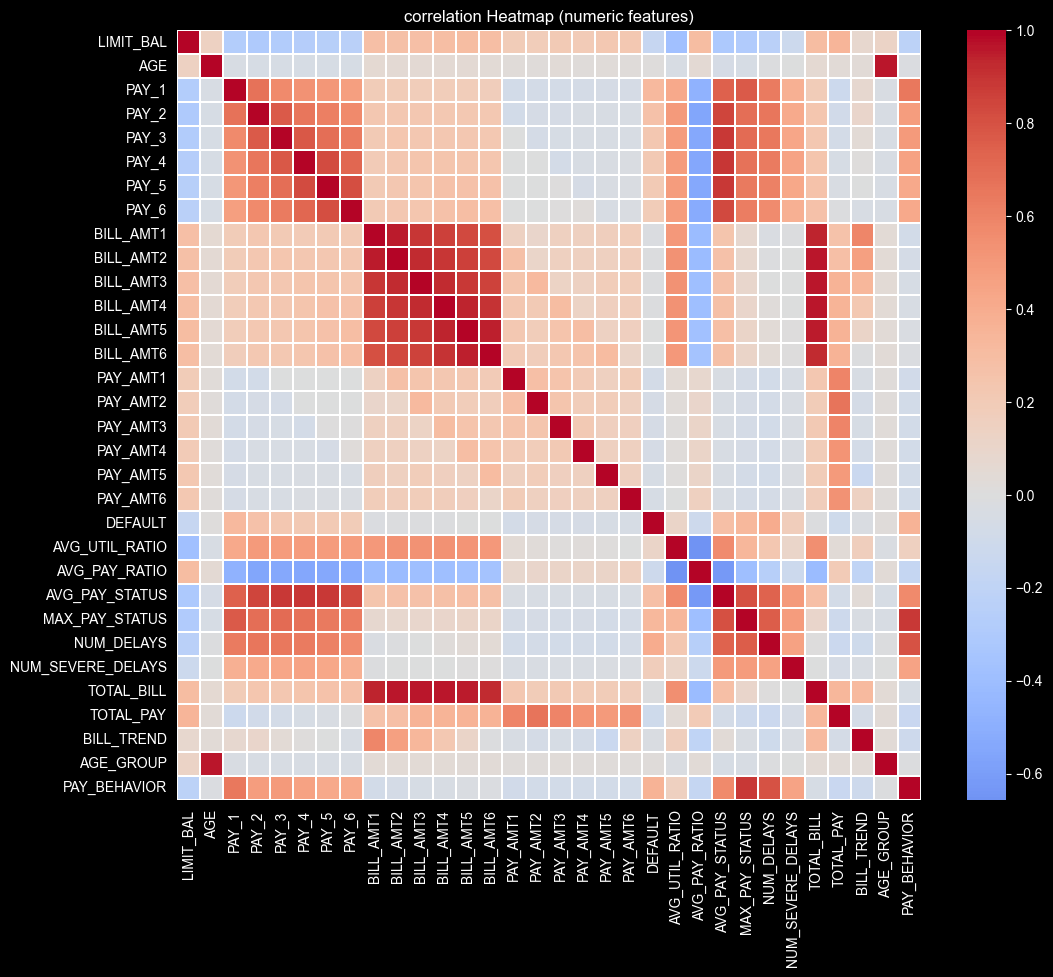

In [132]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()

plt.figure(figsize= (12,10))
sns.heatmap(corr, cmap = "coolwarm", center =0, linewidth= 0.2)
plt.title("correlation Heatmap")
plt.show

Our multicollinearity check shows that monthly bill amounts are highly correlated with each other and with our TOTAL_BILL summary (0.83 to 0.96) - if someone had a high bill in April, they likely had high bills all year. Also, AGE and AGE_GROUP at 0.96 which is not a surprise since we created one from the other.

In [ ]:
print_section_header("FINAL DATASET PREPARATION")

let's examine each of the continuous features and use a Box and scatter plots to visually identify potential outliers and evaluate the distribution of the values across the dataset.

Generating box plots for 32 numerical features...


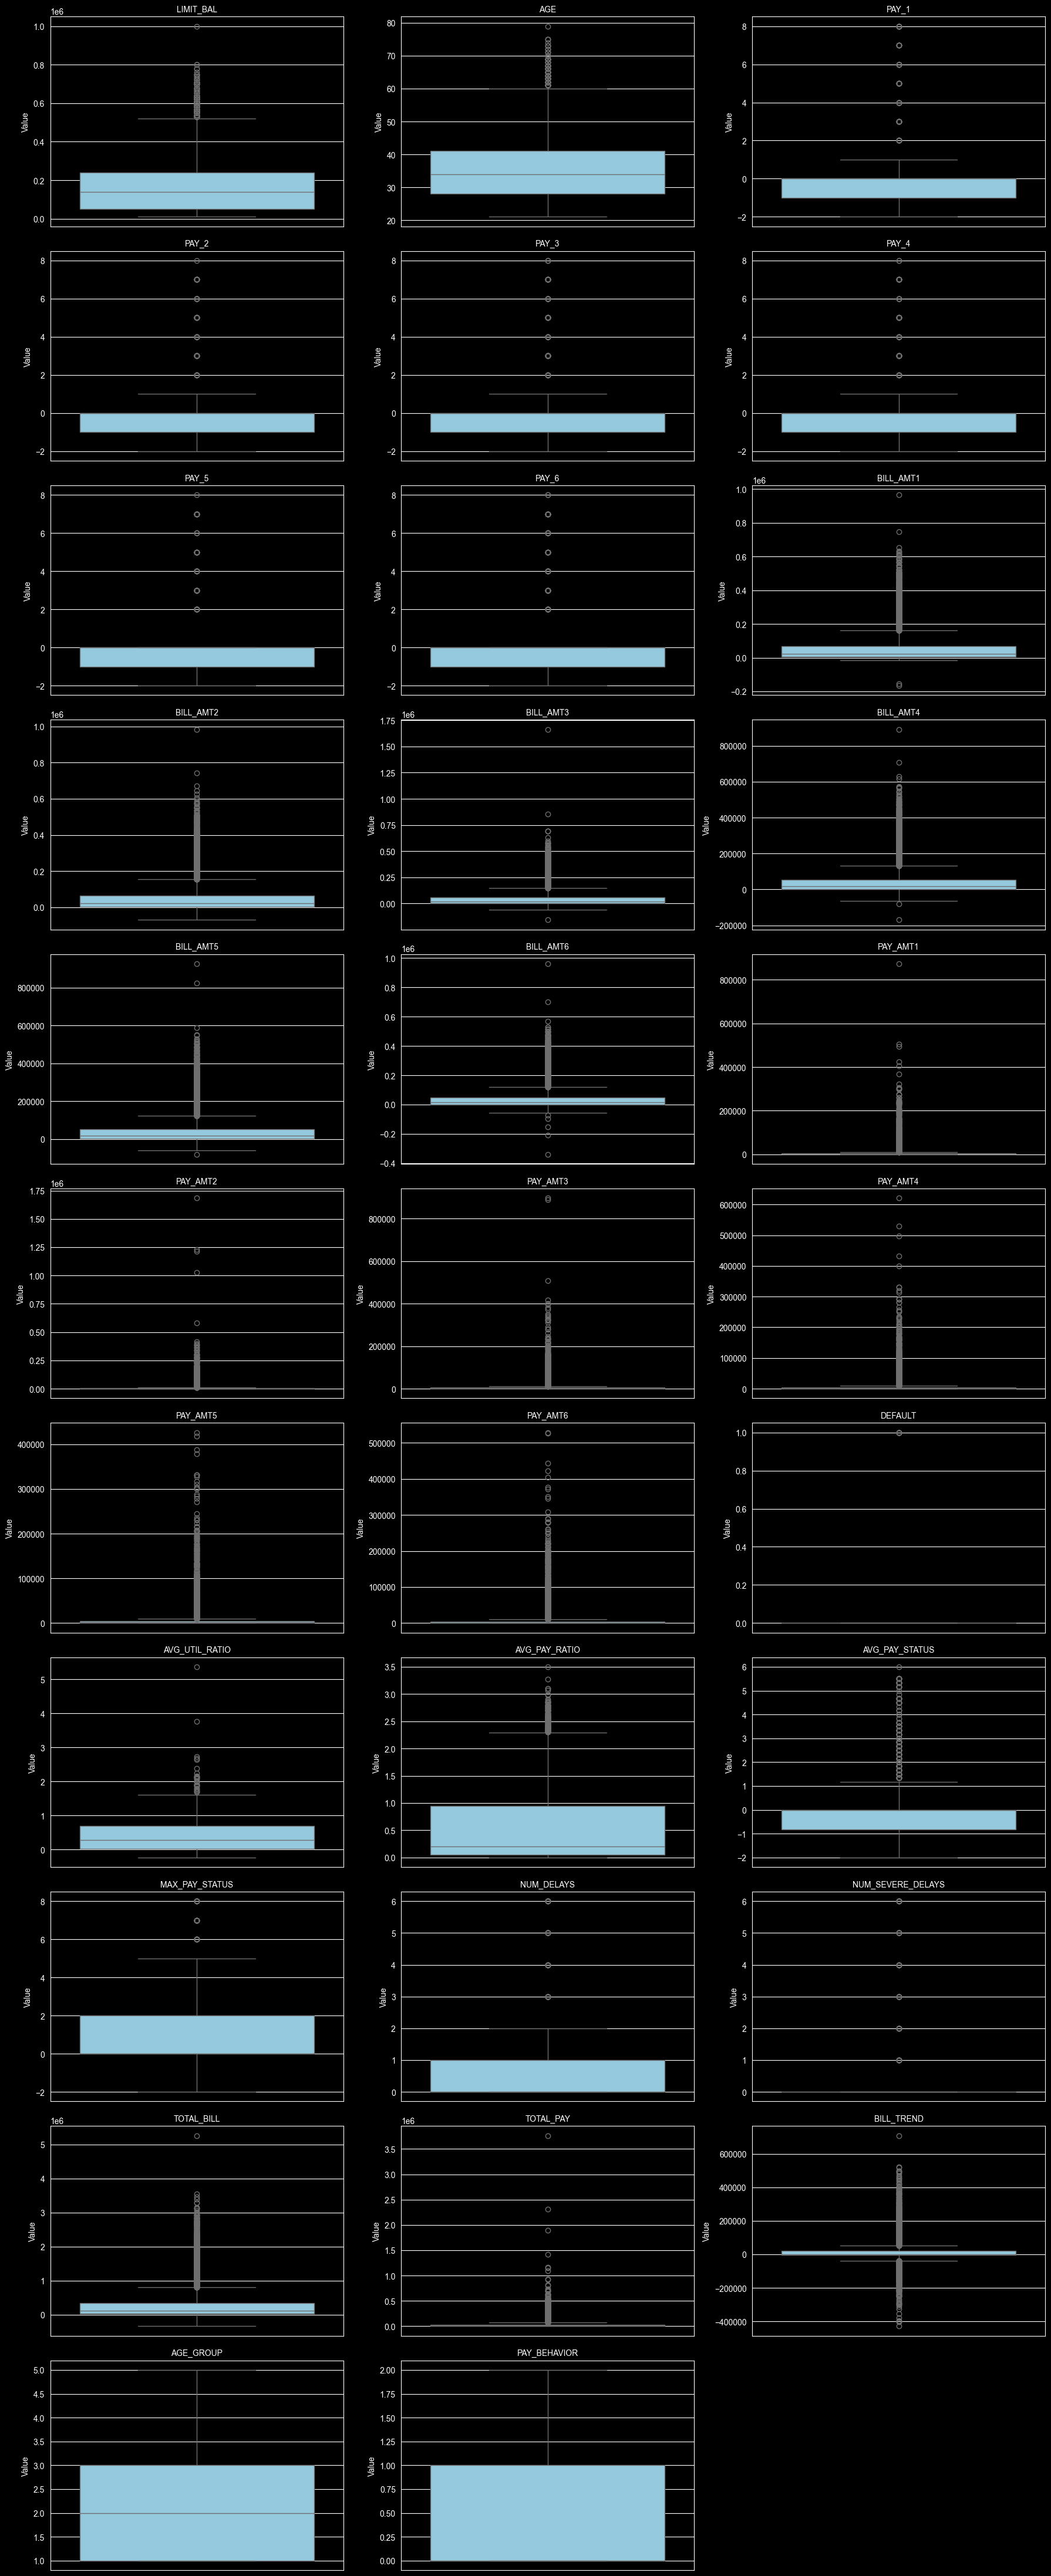

In [130]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Generating box plots for {len(numerical_vars)} numerical features...")

# Number of plots per row
plots_per_row = 3
# Calculate the required number of rows for the subplot grid
rows = math.ceil(len(numerical_vars) / plots_per_row)
# Create a figure with a dynamically scaled size
plt.figure(figsize=(plots_per_row * 6, rows * 4))

# Generate a boxplot for each numerical variable
for i, col in enumerate(numerical_vars, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel('Value')

# Adjust the padding between and around subplots
plt.tight_layout()
plt.show()

Generating scatter plots for 32 numerical features...


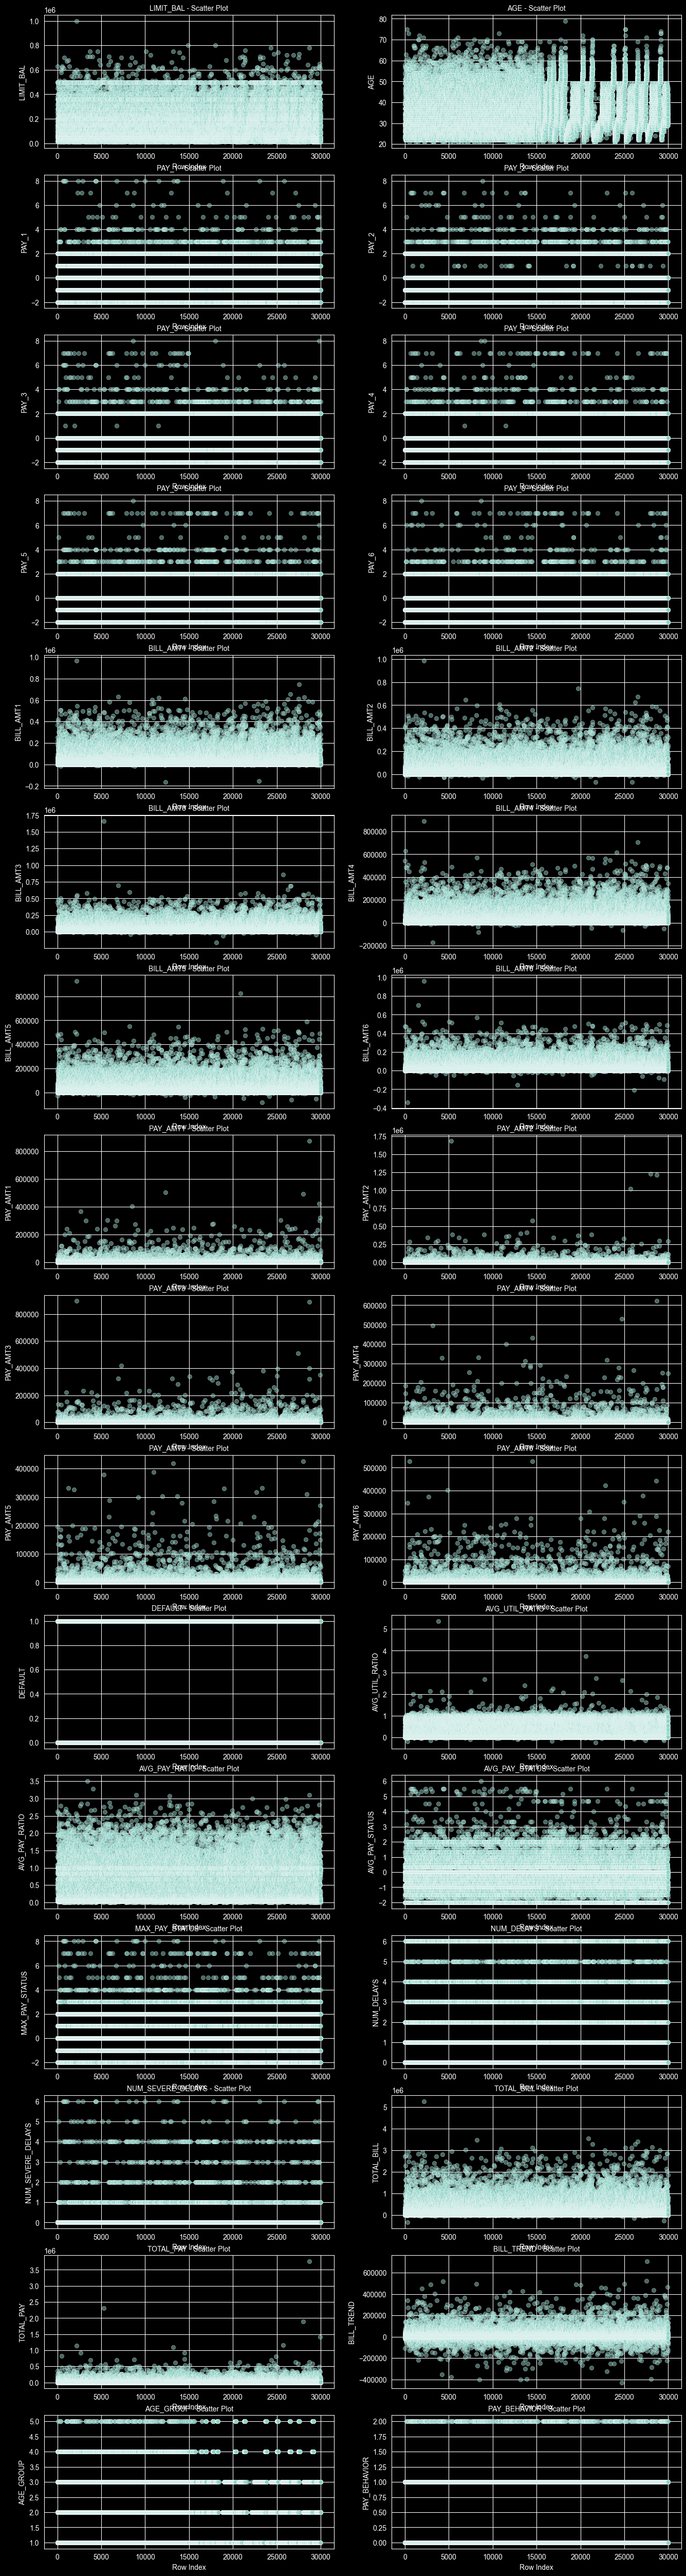

In [131]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Generating scatter plots for {len(numerical_vars)} numerical features...")

# Number of plots per row
plots_per_row = 2
# Calculate the required number of rows for the subplot grid
rows = math.ceil(len(numerical_vars) / plots_per_row)
# Create a figure with a dynamically scaled size
plt.figure(figsize=(plots_per_row * 8, rows * 4))

# Generate a scatter plot for each numerical variable
for i, col in enumerate(numerical_vars, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.scatterplot(data=df, x=df.index, y=col, alpha=0.5)
    plt.title(f"{col} - Scatter Plot", fontsize=10)
    plt.xlabel("Row Index")
    plt.ylabel(col)

In [ ]:
# Features for Task 1 (Default Prediction)
# Remove PAY_BEHAVIOR (it's the Task 2 target, and would leak info)
task1_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
task1_target = 'DEFAULT'

# Features for Task 2 (Payment Behavior Classification)
# Remove DEFAULT (it's the Task 1 target)
# Also remove PAY_1 through PAY_6 since they directly define PAY_BEHAVIOR (data leakage!)
task2_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR',
                                                       'PAY_1', 'PAY_2', 'PAY_3',
                                                       'PAY_4', 'PAY_5', 'PAY_6',
                                                       'AVG_PAY_STATUS', 'MAX_PAY_STATUS',
                                                       'NUM_DELAYS', 'NUM_SEVERE_DELAYS']]
task2_target = 'PAY_BEHAVIOR'
print(f"Task 1 Features ({len(task1_features)}): {task1_features}")
print(f"Task 1 Target: {task1_target}")
print(f"\nTask 2 Features ({len(task2_features)}): {task2_features}")
print(f"Task 2 Target: {task2_target}")


In [134]:
print_section_header("SCALING")

# Check the range of continuous features
continuous_features = ['LIMIT_BAL', 'AGE'] + \
                     [f'BILL_AMT{i}' for i in range(1,7)] + \
                     [f'PAY_AMT{i}' for i in range(1,7)] + \
                     ['AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND']

print("Feature ranges before scaling:")
for feat in continuous_features:
    if feat in df.columns:
        print(f"  {feat:20s}: min={df[feat].min():12.2f}, max={df[feat].max():12.2f}, mean={df[feat].mean():12.2f}, std={df[feat].std():12.2f}")

print("\nNote: StandardScaler will be applied during modeling to normalize features.")

SCALING
Feature ranges before scaling:
  LIMIT_BAL           : min=    10000.00, max=  1000000.00, mean=   167484.32, std=   129747.66
  AGE                 : min=       21.00, max=       79.00, mean=       35.49, std=        9.22
  BILL_AMT1           : min=  -165580.00, max=   964511.00, mean=    51223.33, std=    73635.86
  BILL_AMT2           : min=   -69777.00, max=   983931.00, mean=    49179.08, std=    71173.77
  BILL_AMT3           : min=  -157264.00, max=  1664089.00, mean=    47013.15, std=    69349.39
  BILL_AMT4           : min=  -170000.00, max=   891586.00, mean=    43262.95, std=    64332.86
  BILL_AMT5           : min=   -81334.00, max=   927171.00, mean=    40311.40, std=    60797.16
  BILL_AMT6           : min=  -339603.00, max=   961664.00, mean=    38871.76, std=    59554.11
  PAY_AMT1            : min=        0.00, max=   873552.00, mean=     5663.58, std=    16563.28
  PAY_AMT2            : min=        0.00, max=  1684259.00, mean=     5921.16, std=    23040.87
 

## Model Classifications

In [ ]:
#DEFAULT
x_default =df[task1_features]
y_default = df[task1_target]

x_train_default, x_test_default, y_train_default, y_test_default = train_test_split(

    x_default,y_default,test_size=0.2, random_state=42, stratify=y_default

)


In [ ]:

#PAY_BEHAVIOR
x_pay =df[task2_features]
y_pay = df[task2_target]

x_train_pay, x_test_pay, y_train_pay, y_test_pay = train_test_split(

    x_pay,y_pay,test_size=0.2, random_state=42, stratify=y_pay

)

# Logistic Regression

In [ ]:
log_model = Pipeline(
    [("scaler", StandardScaler()),
     ("clf", LogisticRegression(max_iter=2000, random_state=42))]
)

# KNN

In [ ]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

# Random Forrest

In [ ]:
random_forrest_model = RandomForestClassifier(random_state=42)

# Tuning Parameters

In [ ]:
##Logistic Regression tuning DEFAULT

for c in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=c, max_iter=2000, random_state=42))
    ])
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("C =", c, "F1 =", score)

In [ ]:
##Logistic Regression tuning PAY_BEHAVIOR

for c in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=c, max_iter=2000, random_state=42))
    ])
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("C =", c, "F1 =", score)

In [ ]:
##KNN tuning DEFAULT
for k in [3, 5, 7, 9]:
    model = Pipeline([
        ("scaler", StandardScaler()),
         ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("k =", k, "F1 =", score)

In [ ]:
##KNN tuning PAY_BEHAVIOR
for k in [3, 5, 7, 9]:
    model = Pipeline([
        ("scaler", StandardScaler()),
         ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("k =", k, "F1 =", score)

In [ ]:
##Random Forrest tuning DEFAULT
for depth in [None, 5, 10, 20]:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("max_depth =", depth, "F1 =", score)


In [ ]:
##Random Forrest tuning PAY_BEHAVIOR
for depth in [None, 5, 10, 20]:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("max_depth =", depth, "F1 =", score)

## Evaluate Models

In [ ]:
#DEFAULT
tuned_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.01, max_iter=2000, random_state=42))
])

tuned_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=7))
])

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {
    "Logistic Regression": tuned_log_model,
    "KNN": tuned_knn_model,
    "Random Forest": tuned_random_forrest_model
}

for name, model in models.items():
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_default, y_pred))
    print("Precision:", precision_score(y_test_default, y_pred, average="macro"))
    print("Recall:", recall_score(y_test_default, y_pred, average="macro"))
    print("F1:", f1_score(y_test_default, y_pred, average="macro"))
    print(classification_report(y_test_default, y_pred))

In [ ]:

#PAY_BEHAVIOR
tuned_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=10, max_iter=2000, random_state=42))
])

tuned_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=3))
])

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {
    "Logistic Regression": tuned_log_model,
    "KNN": tuned_knn_model,
    "Random Forest": tuned_random_forrest_model
}

for name, model in models.items():
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_pay, y_pred))
    print("Precision:", precision_score(y_test_pay, y_pred, average="macro"))
    print("Recall:", recall_score(y_test_pay, y_pred, average="macro"))
    print("F1:", f1_score(y_test_pay, y_pred, average="macro"))
    print(classification_report(y_test_pay, y_pred))



For DEFAULT, the tuned Logistic Regression model used C = 0.01, the tuned KNN model used k = 7, and the tuned Random Forest model used max_depth = 20. Among these, Random Forest performed best with an accuracy of 0.8143 and a macro F1 score of 0.6768. KNN was second-best with a macro F1 of 0.6594, followed by Logistic Regression at 0.6450.

For PAY_BEHAVIOR, the tuned Logistic Regression model used C = 10, the tuned KNN model used k = 3, and the tuned Random Forest model used max_depth = 20. Random Forest again performed best, with an accuracy of 0.8815 and a macro F1 score of 0.7884. This was substantially better than KNN, which achieved a macro F1 of 0.4261, and Logistic Regression, which achieved 0.3692.

Overall, Random Forest was the strongest model for both prediction tasks. The results suggest that nonlinear relationships in the data were important, especially for predicting PAY_BEHAVIOR, where the tree-based ensemble model greatly outperformed the linear and distance-based methods.